# 02 Exercise: Tree Age Prediction

In this exercise, you apply supervised regression to a very different type of data: an urban tree inventory.

The business goal is to estimate missing tree age information for a city administration.

## Learning Goals

By the end of this exercise, you should be able to:

- translate a public-sector data quality problem into a supervised learning task,
- construct a regression target from available administrative data,
- distinguish labeled records from unlabeled inference candidates,
- build a preprocessing and modeling pipeline for mixed tabular data,
- evaluate regression models in interpretable units,
- inspect model errors across operational segments.

## Business Context

A city administration manages a large tree inventory. For many trees, the planting year is missing or unreliable. This means the actual tree age is unknown.

Missing tree age creates practical problems:

- **Maintenance planning**: young, mature, and old trees may require different inspection and care intervals.
- **Risk prioritization**: older trees may need closer checks depending on species, location, and condition.
- **Budget planning**: the city needs to estimate future care, replacement, and replanting needs.
- **Climate adaptation**: the age structure helps assess whether the urban tree population is balanced and resilient.
- **Data quality management**: estimated age can help flag records for later field validation.

The model should not silently overwrite official records. It should produce an estimate that can support prioritization and data quality workflows.

## Dataset

We use the Berlin tree inventory from the old course material.

Target construction:

```python
tree_age = 2025 - pflanzjahr
```

Important: `pflanzjahr` is only used to construct the label. It must not be used as a model feature. Trees without `pflanzjahr` are unlabeled inference candidates.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
REFERENCE_YEAR = 2025
TRAINING_SAMPLE_SIZE = 50_000


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "raw" / "tree_inventory" / "baumkataster_berlin_2025.parquet").exists():
            return path
    raise FileNotFoundError("Could not find tree inventory parquet file in data/raw/tree_inventory.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "tree_inventory" / "baumkataster_berlin_2025.parquet"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")


Project root: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master
Data path: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/data/raw/tree_inventory/baumkataster_berlin_2025.parquet


## 2. Load Data

In [3]:
df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()


(511872, 19)


,id,standortnr,kennzeich,namenr,art_dtsch,art_bot,gattung_deutsch,gattung,art_gruppe,pflanzjahr,standalter,kronedurch,stammumfg,baumhoehe,eigentuemer,bezirk,geometry,lon,lat
0,anlagenbaeume.00008100_000be4d0,066,411.232,Weigandufer,Eingriffliger Weissdorn,Crataegus monogyna,WEIßDORN,CRATAEGUS,Laubbäume,1989,36.0,NaN,60.0,NaN,Land Berlin,Neukölln,"b'\x01\x01\x00\x00\x00B\xd0M""\xf7\x15\x18A\x89...",13.448252,52.481547
1,anlagenbaeume.00008100_000be4d2,059,411.232,Weigandufer,Hahnensporn-Weissdorn,Crataegus crus-galli,WEIßDORN,CRATAEGUS,Laubbäume,1994,31.0,NaN,37.0,NaN,Land Berlin,Neukölln,b'\x01\x01\x00\x00\x00+\x19|!\x91\x16\x18A\x13...,13.448804,52.481966
2,anlagenbaeume.00008100_000be4f2,062,411.232,Weigandufer,Pflaumenblättriger Weiss-Dorn,Crataegus prunifolia,WEIßDORN,CRATAEGUS,Laubbäume,1987,38.0,NaN,65.0,NaN,Land Berlin,Neukölln,b'\x01\x01\x00\x00\x00\xb4Z\xdcFM\x16\x18A\x9e...,13.448561,52.481775
3,anlagenbaeume.00008100_000bf296,14,221.068,Roetepfuhl-Grünanlage,Gemeine Rosskastanie,Aesculus hippocastanum,ROSSKASTANIE,AESCULUS,Laubbäume,1985,40.0,NaN,128.0,NaN,Land Berlin,Neukölln,b'\x01\x01\x00\x00\x00\xe7\xaf\x0c\xb1\xbf\xff...,13.428736,52.441594
4,anlagenbaeume.00008100_000bf297,13,221.068,Roetepfuhl-Grünanlage,Gemeine Rosskastanie,Aesculus hippocastanum,ROSSKASTANIE,AESCULUS,Laubbäume,1985,40.0,NaN,112.0,NaN,Land Berlin,Neukölln,b'\x01\x01\x00\x00\x00\x03\x9b\xef\xa7\xd4\xff...,13.428811,52.441645


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 511872 entries, 0 to 511871
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               511872 non-null  str    
 1   standortnr       506948 non-null  str    
 2   kennzeich        506952 non-null  str    
 3   namenr           506952 non-null  str    
 4   art_dtsch        500468 non-null  str    
 5   art_bot          500471 non-null  str    
 6   gattung_deutsch  478377 non-null  str    
 7   gattung          500468 non-null  str    
 8   art_gruppe       500468 non-null  str    
 9   pflanzjahr       324715 non-null  Int64  
 10  standalter       331382 non-null  float64
 11  kronedurch       344768 non-null  float64
 12  stammumfg        496449 non-null  float64
 13  baumhoehe        429897 non-null  float64
 14  eigentuemer      506952 non-null  str    
 15  bezirk           506952 non-null  str    
 16  geometry         511872 non-null  object 
 17  lo

## 3. Data Exploration

Explore the inventory before modeling.

Questions:

- How many records have a known planting year?
- How old are the trees with known age?
- Which districts and tree groups are common?
- Which measurement columns contain missing or implausible values?

In [5]:
missing_share = df.isna().mean().sort_values(ascending=False)
missing_share.head(15).round(3)

pflanzjahr         0.366
standalter         0.353
kronedurch         0.326
baumhoehe          0.160
gattung_deutsch    0.065
stammumfg          0.030
art_gruppe         0.022
gattung            0.022
art_dtsch          0.022
art_bot            0.022
standortnr         0.010
bezirk             0.010
kennzeich          0.010
namenr             0.010
eigentuemer        0.010
dtype: float64

In [6]:
df["bezirk"].value_counts(dropna=False).head(15)

bezirk
Pankow                        56896
Steglitz-Zehlendorf           51607
Marzahn-Hellersdorf           49253
Spandau                       48703
Lichtenberg                   47692
Reinickendorf                 47615
Charlottenburg-Wilmersdorf    45253
Mitte                         39145
Neukölln                      36035
Treptow-Köpenick              33587
Tempelhof-Schöneberg          26265
Friedrichshain-Kreuzberg      24901
NaN                            4920
Name: count, dtype: int64

In [7]:
df["art_gruppe"].value_counts(dropna=False)

art_gruppe
Laubbäume        453213
Nadelbäume        44789
NaN               11404
Obstbäume          1247
Großsträucher      1209
Sträucher            10
Name: count, dtype: int64

## 4. Target Construction and Cleaning

In [8]:
df = df.copy()

# Basic data quality rules for this exercise.
df.loc[df["pflanzjahr"].lt(1800) | df["pflanzjahr"].gt(REFERENCE_YEAR), "pflanzjahr"] = pd.NA
for column in ["kronedurch", "stammumfg", "baumhoehe"]:
    df.loc[df[column].eq(0), column] = np.nan

# Business target: tree age in years.
df["tree_age"] = REFERENCE_YEAR - df["pflanzjahr"]

# Simple feature engineering from current tree measurements and location.
df["height_to_crown_ratio"] = df["baumhoehe"] / df["kronedurch"].replace(0, np.nan)
df["height_to_trunk_ratio"] = df["baumhoehe"] / df["stammumfg"].replace(0, np.nan)
df["lon_bin"] = df["lon"].round(2).astype("string")
df["lat_bin"] = df["lat"].round(2).astype("string")

labeled = df[df["tree_age"].notna()].copy()
unlabeled = df[df["tree_age"].isna()].copy()

print(f"Labeled trees: {len(labeled):,}")
print(f"Unlabeled inference candidates: {len(unlabeled):,}")


Labeled trees: 324,599
Unlabeled inference candidates: 187,273


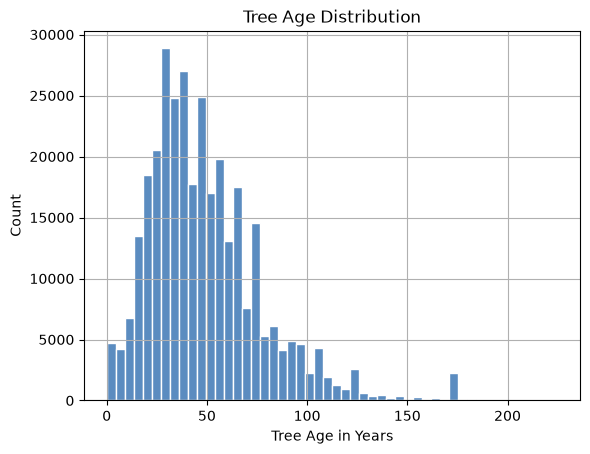

In [9]:
ax = labeled["tree_age"].hist(bins=50, color="#5b8cc0", edgecolor="white")
ax.set_title("Tree Age Distribution")
ax.set_xlabel("Tree Age in Years")
ax.set_ylabel("Count")
plt.show()

## 5. Feature Set

Select features that could plausibly be known for trees with missing age.

Do not use:

- `pflanzjahr`, because it defines the label,
- `standalter`, because it is directly derived from age,
- technical identifiers as predictors.

In [10]:
target_column = "tree_age"
label_source_columns = ["pflanzjahr", "standalter"]
identifier_columns = ["id", "standortnr", "kennzeich", "geometry"]

feature_columns = [
    "art_gruppe",
    "gattung_deutsch",
    "gattung",
    "bezirk",
    "eigentuemer",
    "kronedurch",
    "stammumfg",
    "baumhoehe",
    "lon",
    "lat",
    "height_to_crown_ratio",
    "height_to_trunk_ratio",
    "lon_bin",
    "lat_bin",
]

model_data = labeled[feature_columns + [target_column]].copy()
model_data = model_data.sample(
    n=min(TRAINING_SAMPLE_SIZE, len(model_data)),
    random_state=RANDOM_STATE,
)

X = model_data[feature_columns]
y = model_data[target_column].astype(float)

print(X.shape)
print(y.describe().round(2))


(50000, 14)
count    50000.00
mean        48.80
std         28.88
min          1.00
25%         29.00
50%         43.00
75%         63.00
max        225.00
Name: tree_age, dtype: float64


## 6. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_test.shape)


(40000, 14) (10000, 14)


## 7. Preprocessing Pipeline

In [12]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['kronedurch', 'stammumfg', 'baumhoehe', 'lon', 'lat', 'height_to_crown_ratio', 'height_to_trunk_ratio']
Categorical features: ['art_gruppe', 'gattung_deutsch', 'gattung', 'bezirk', 'eigentuemer', 'lon_bin', 'lat_bin']


## 8. Evaluation Function

For this problem, `MAE` is especially intuitive.

If `MAE = 8`, the model is wrong by about 8 years on average. Whether that is acceptable depends on the administrative use case.

In [13]:
def regression_metrics(y_true, y_pred, model_name: str) -> dict:
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "model_name": model_name,
        "mae_years": mean_absolute_error(y_true, y_pred),
        "rmse_years": rmse,
        "r2": r2_score(y_true, y_pred),
    }


def plot_regression_errors(y_true, y_pred, model_name: str) -> None:
    errors = y_pred - y_true
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(errors, bins=40, color="#5b8cc0", edgecolor="white")
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set_title("Prediction Error Distribution")
    axes[0].set_xlabel("Predicted Age - Actual Age")
    axes[0].set_ylabel("Count")

    axes[1].scatter(y_true, y_pred, alpha=0.25, s=10, color="#5aa469")
    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    axes[1].plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--")
    axes[1].set_title("Predicted vs. Actual Tree Age")
    axes[1].set_xlabel("Actual Age")
    axes[1].set_ylabel("Predicted Age")

    fig.suptitle(model_name)
    plt.tight_layout()
    plt.show()


## 9. Baseline Model

In [14]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median")),
    ]
)

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

# TODO: Fit and evaluate both baseline models.
# dummy_model.fit(X_train, y_train)
# linear_model.fit(X_train, y_train)
# dummy_pred = dummy_model.predict(X_test)
# linear_pred = linear_model.predict(X_test)
# baseline_results = [
#     regression_metrics(y_test, dummy_pred, "Median Baseline"),
#     regression_metrics(y_test, linear_pred, "Linear Regression"),
# ]
# pd.DataFrame(baseline_results).round(3)

## 10. More Complex Model: XGBoost Regressor

In [15]:
xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=250,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=10,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# TODO: Fit and evaluate the XGBoost model.
# xgboost_model.fit(X_train, y_train)
# xgb_pred = xgboost_model.predict(X_test)
# xgb_result = regression_metrics(y_test, xgb_pred, "XGBoost")
# xgb_result

## 11. Error Analysis and Slicing

Inspect whether prediction errors differ across operational segments.

Suggested slices:

- `bezirk`
- `art_gruppe`
- `gattung_deutsch`

Questions:

- In which districts is the model less accurate?
- Are some tree groups harder to estimate?
- Are small groups driving unstable metrics?

In [16]:
# TODO: Build a prediction dataframe for the selected model and calculate slice-level MAE.
# selected_model = xgboost_model
# selected_pred = selected_model.predict(X_test)
#
# predictions = X_test.copy()
# predictions["y_true"] = y_test
# predictions["y_pred"] = selected_pred
# predictions["absolute_error"] = (predictions["y_pred"] - predictions["y_true"]).abs()
#
# def regression_slice_metrics(data: pd.DataFrame, column: str) -> pd.DataFrame:
#     return (
#         data.groupby(column, dropna=False)
#         .agg(
#             n=("absolute_error", "size"),
#             mean_tree_age=("y_true", "mean"),
#             mae_years=("absolute_error", "mean"),
#         )
#         .reset_index()
#         .rename(columns={column: "slice_value"})
#         .sort_values("mae_years", ascending=False)
#     )
#
# regression_slice_metrics(predictions, "bezirk").head(15)

## 12. Inference Candidates

Trees without a known `pflanzjahr` do not have a training label. After a model is selected, these records could be scored as inference candidates.

The predicted age should be treated as an estimate, not as verified ground truth.

In [17]:
# TODO: Score a small sample of unlabeled trees.
# inference_sample = unlabeled[feature_columns].sample(10, random_state=RANDOM_STATE)
# predicted_age = selected_model.predict(inference_sample)
# inference_sample.assign(predicted_tree_age=np.round(predicted_age, 1))

## 13. Reflection

Write a short reflection.

Questions:

- Is the model accurate enough for maintenance prioritization?
- Would you use exact predicted age or age bands?
- Which missing features would improve the model?
- How should uncertainty be communicated to the administration?
- What should be monitored if predictions are used operationally?